In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [61]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
!ls /content/drive/MyDrive/MLAS\ 500/HW1

 cifar-10-batches-py  'HW1&2.ipynb'


In [64]:
getbatch = unpickle("/content/drive/MyDrive/MLAS 500/HW1/cifar-10-batches-py/data_batch_1")



In [65]:
getbatch.keys()

dict_keys([b'batch_label', b'labels', b'data', b'filenames'])

In [66]:
x = getbatch[b'data']
y = getbatch[b'labels']

In [67]:
x.shape

(10000, 3072)

In [68]:
x = x.reshape(-1, 3, 32, 32)

In [69]:
# base path to your CIFAR-10 folder
base_path = "/content/drive/MyDrive/MLAS 500/HW1/cifar-10-batches-py"

train_data = []
train_labels = []

for i in range(1, 6):
    batch_file = f"{base_path}/data_batch_{i}"
    batch = unpickle(batch_file)
    train_data.append(batch[b'data'])
    train_labels.extend(batch[b'labels'])

# Combine and reshape
x_train = np.concatenate(train_data).reshape(-1, 3, 32, 32)
x_train = np.transpose(x_train, (0, 2, 3, 1))  # shape (50000, 32, 32, 3)
y_train = np.array(train_labels)                 # shape (50000,)


In [70]:
test_file = f"{base_path}/test_batch"
test_batch = unpickle(test_file)

x_test = test_batch[b'data'].reshape(-1, 3, 32, 32)
x_test = np.transpose(x_test, (0, 2, 3, 1))
y_test = np.array(test_batch[b'labels'])


In [71]:
print(x_train.shape, y_train.shape)  # (50000, 32, 32, 3) (50000,)
print(x_test.shape, y_test.shape)    # (10000, 32, 32, 3) (10000,)

(50000, 32, 32, 3) (50000,)
(10000, 32, 32, 3) (10000,)


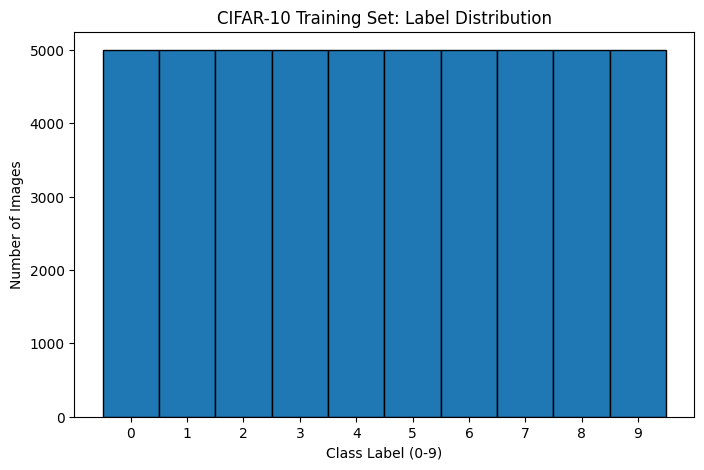

In [72]:
plt.figure(figsize=(8,5))
plt.hist(y_train, bins=range(11), edgecolor='black', align='left')
plt.xticks(range(10))
plt.xlabel('Class Label (0-9)')
plt.ylabel('Number of Images')
plt.title('CIFAR-10 Training Set: Label Distribution')
plt.show()



Observations: Labels are evenly distributed between all classes of images. All Images are labeled.

In [75]:
# N = number of batches
# H = Height of image
# W = Width of image
# C = Noofchannels

def getbatch(alldata, alllabels, batch_size=16):

    N = alldata.shape[0]

    # Shuffle the data at the start of each epoch
    indices = np.arange(N)
    np.random.shuffle(indices)

    for start_idx in range(0, N, batch_size):
        end_idx = min(start_idx + batch_size, N)
        batch_idx = indices[start_idx:end_idx]

        x_batch = alldata[batch_idx]
        y_batch = alllabels[batch_idx]

        # If input is (N, H, W, C), convert to (N, C, H, W)
        if x_batch.shape[-1] in [1, 3]:
            x_batch = np.transpose(x_batch, (0, 3, 1, 2))

        yield x_batch, y_batch


In [76]:
batch_size = 16
batch_gen = getbatch(x_train, y_train, batch_size=batch_size)

# Get first batch
x_batch, y_batch = next(batch_gen)

print(x_batch.shape)
print(y_batch.shape)


(16, 3, 32, 32)
(16,)
